<a href="https://colab.research.google.com/github/Waffle0823/Supervised-Learning/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install keras

In [6]:
!pip install np_utils

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9252 - loss: 0.2441 - val_accuracy: 0.9701 - val_loss: 0.1016
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9654 - loss: 0.1109 - val_accuracy: 0.9719 - val_loss: 0.0919
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9737 - loss: 0.0846 - val_accuracy: 0.9745 - val_loss: 0.0865
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9790 - loss: 0.0660 - val_accuracy: 0.9763 - val_loss: 0.0861
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9814 - loss: 0.0573 - val_accuracy: 0.9764 - val_loss: 0.0864


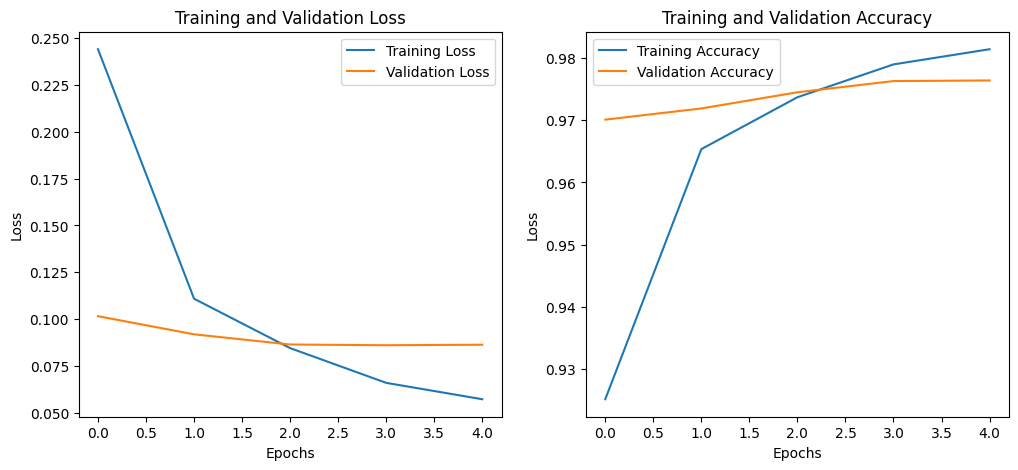

In [41]:
from keras.utils import to_categorical
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout
import matplotlib.pyplot as plt
import numpy as np

# save mnist.load_data() result tuple as (x_train, y_train) (x_test, y_test)
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reshape x_train data as 784 length arrays of 60000 datasets
# Convert pixel data as float32
# Normalize data by deviding 255
x_train = x_train.reshape(60000, 784).astype('float32') / 255.0

# Reshape x_test data as 784 length arrays of 60000 datasets
# Convert pixel data as float32
# Normalize data by deviding 255
x_test = x_test.reshape(10000, 784).astype('float32') / 255.0

# One Hot Encoding (Convert data from number to array)
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# define plot_sample_images function
def plot_sample_images(x_data, y_data, num_classes=10):
  # Create a new top level container
  plt.figure(figsize=(10, 10))

  # Iterate for num_classes
  for i in range(num_classes):
    # Get index of y_data[:, i] == 1[0]
    idxs = np.where(y_data[:, i] == 1)[0]
    idx = np.random.choice(idxs)

    # Get image data from x_data[idx] and reshape data to 28 by 28
    img = x_data[idx].reshape(28, 28)

    plt.subplot(1, num_classes, i+1)

    # Create readable image
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(f"Label: {i}")

  # Show image
  plt.show()

# for i in range(10):
#   plot_sample_images(x_train, y_train)

# 0~50000 is train data and 50001~end
x_train, x_val = x_train[:50000], x_train[50000:]
y_train, y_val = y_train[:50000], y_train[50000:]

model = Sequential()

# Input
model.add(Dense(512, input_dim=28*28, activation='relu'))
model.add(Dropout(0.2))

# Hide
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))

# Output
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

hist = model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_val, y_val))

plt.figure(figsize=(12, 5))

# Figure of Training and Validation Loss
plt.subplot(1, 2, 1)
plt.plot(hist.history['loss'], label="Training Loss")
plt.plot(hist.history['val_loss'], label="Validation Loss")
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')

plt.subplot(1, 2, 2)
plt.plot(hist.history['accuracy'], label="Training Accuracy")
plt.plot(hist.history['val_accuracy'], label="Validation Accuracy")
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Accuracy')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
## yhat ###
[[3.3748652e-13 9.6765993e-15 1.1753118e-11 2.1435195e-08 2.5286715e-08
  1.7846237e-09 1.2646869e-16 7.7521367e-10 1.6536858e-10 1.0000000e+00]]


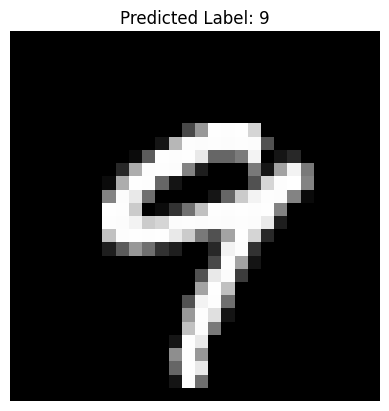

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
## yhat ###
[[8.6159899e-11 3.6989124e-07 4.7584590e-06 4.1181400e-07 5.5266555e-12
  1.2980619e-10 2.3383727e-14 9.9999416e-01 2.5331945e-08 3.6991170e-07]]


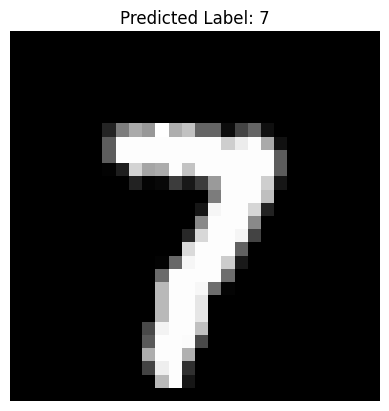

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
## yhat ###
[[3.5935989e-18 2.7312301e-17 1.0000000e+00 8.1032073e-12 4.8712526e-15
  2.3440851e-21 1.0643472e-17 2.6974469e-15 2.6002011e-16 2.5907899e-20]]


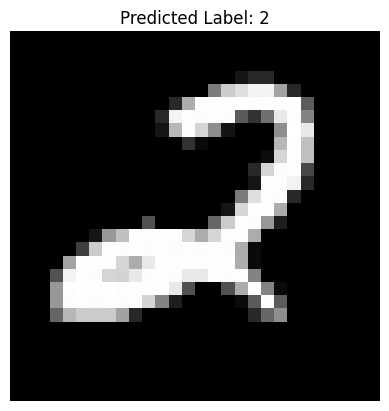

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
## yhat ###
[[4.7071138e-05 1.4980235e-06 5.2301066e-06 4.9945357e-04 5.9396083e-08
  5.2023660e-07 3.3798887e-07 9.8230828e-08 9.9942273e-01 2.2977405e-05]]


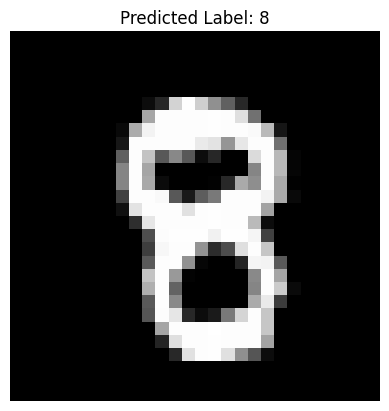

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
## yhat ###
[[2.1289044e-09 7.7700868e-09 3.1561678e-09 1.9305102e-07 4.3807737e-05
  7.3083243e-08 2.9049328e-12 6.7825706e-05 4.3611625e-08 9.9988806e-01]]


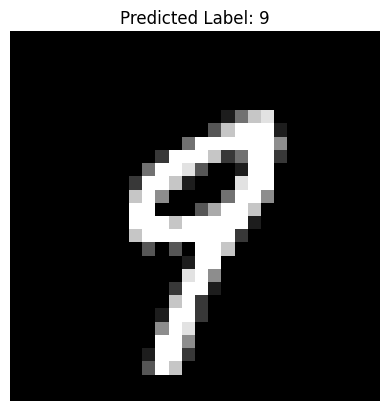

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
## yhat ###
[[3.6337632e-12 1.3594637e-07 1.0850306e-09 1.7148330e-11 9.9999928e-01
  1.5375276e-10 7.4006212e-10 7.6076162e-10 6.5371734e-07 4.1436850e-09]]


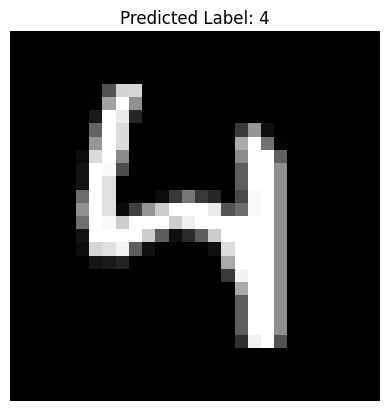

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
## yhat ###
[[1.3697755e-08 2.1368267e-09 5.5060315e-08 1.7647731e-06 7.7103545e-07
  3.3854328e-06 5.2848368e-12 5.8607216e-06 5.5067460e-08 9.9998808e-01]]


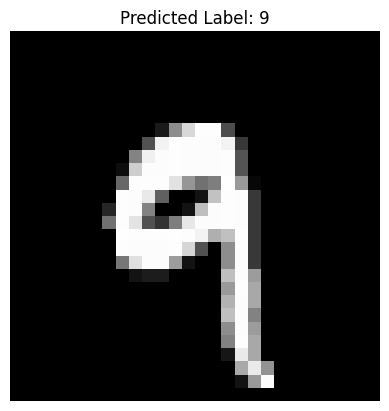

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
## yhat ###
[[2.2377666e-04 1.0162976e-11 7.9909690e-10 1.6431709e-10 5.5230226e-10
  5.7145033e-05 9.9971908e-01 1.0292512e-10 1.4903945e-09 1.9065537e-08]]


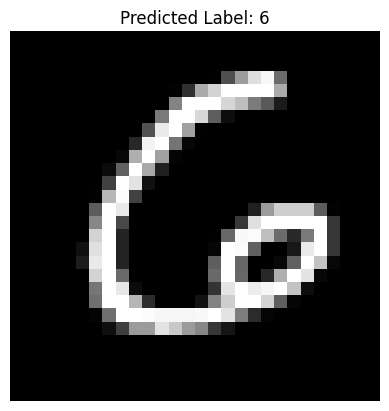

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
## yhat ###
[[2.7593996e-04 7.7135177e-05 1.6337571e-04 2.3337766e-04 1.8605353e-04
  8.7814349e-01 9.1812797e-02 2.3266500e-04 2.4377381e-02 4.4977176e-03]]


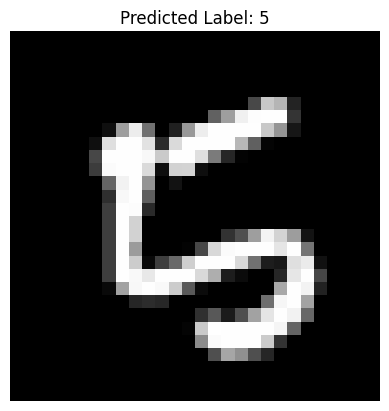

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
## yhat ###
[[1.0000000e+00 8.8559988e-15 7.3347932e-09 4.2832070e-12 1.1967105e-12
  3.6016917e-13 3.7940129e-10 5.6616569e-12 1.6228702e-10 7.1128514e-10]]


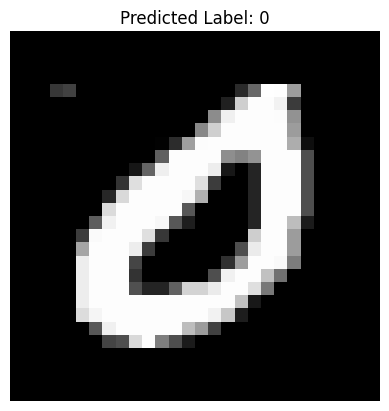

In [109]:
import numpy as np
import matplotlib.pyplot as plt

def model_test(model):
  idx = np.random.randint(0, len(x_test))

  xhat = x_test[idx:idx+1]
  yhat = model.predict(xhat)

  print('## yhat ###')
  print(yhat)

  plt.imshow(xhat.reshape(28, 28), cmap='gray')
  plt.title(f"Predicted Label: {np.argmax(yhat)}")
  plt.axis('off')
  plt.show()

for i in range(10):
  model_test(model)